In [1]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from functions import preprocess, export_weights, export_matrix_to_mem

# Importação e processamento do Dataset

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

'Really, REALLY... What pleases audience (american one!) in this so called show is totally beyond me. What can we learn from these series:<br /><br />1. Each casino there is spending about 2-3 billion bucks every year to rent a satellite and enormous quantity of hi tech high resolution cameras for their security team. Let FBI bites the dust of them.<br /><br />2. Every security employee must have voluptuous breasts, of course natural ones. The tits must be shown all the time otherwise they will lose their job. <br /><br />3. If the employee happens to be a male, he needs to get breasts implanted, then go to step 2. <br /><br />4. Only in Hollywood one can blatantly rip off other show\'s ideas then implement them as their own and call all this crap "original" and "art". <br /><br />5. Every security with tits bigger than 39D is considered immortal and cannot die.<br /><br />I really would like to have the opportunity to vote with minus values. -10/10 for this one!'

In [5]:
print(preprocess(df.iloc[random_num]['review']))

really really pleases audience american one called show totally beyond learn series casino spending billion buck every year rent satellite enormous quantity tech high resolution camera security team let fbi bite dust every security employee must voluptuous breast course natural one tit must shown time otherwise lose job employee happens male need get breast implanted step hollywood one blatantly rip show idea implement call crap original art every security tit bigger considered immortal die really would like opportunity vote minus value one


In [6]:
df['review'] = df['review'].apply(preprocess)

In [7]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [8]:
n_words = [len(i.split(" ")) for i in df['review']]
print(f"Quantidade média de tokens {np.mean(n_words)}")
print(f"Mediana de tokens {np.median(n_words)}")

Quantidade média de tokens 116.49538
Mediana de tokens 86.0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [10]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [11]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [12]:
max_len = 20

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [13]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(16, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(16, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 4)          │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 20, 4)          │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,633 (318.88 KB)

 Trainable params: 81,633 (318.88 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [15]:
""" lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)"""

' lstm_history = lstm_model.fit(\n    X_train_pad, y_train,\n    epochs=100,\n    batch_size=128,   \n    validation_split=0.2,\n    callbacks=[early_stop, reduce_lr],\n    verbose=1\n)'

In [16]:
#lstm_model.save_weights("lstm_modelo_leve.weights.h5")

In [17]:

lstm_model.load_weights("lstm_modelo_leve.weights.h5")

c:\Users\jose.sales\AppData\Local\miniconda3\envs\ilumpy\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [18]:
#Comentado por não ser acessário treinar rede novamente

""" plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()"""

' plt.figure(figsize=(10,5))\n\nplt.plot(lstm_history.history[\'accuracy\'], label=\'Train Acc\')\nplt.plot(lstm_history.history[\'val_accuracy\'], label=\'Val Acc\')\n\nplt.title("Model Accuracy")\nplt.xlabel("Epoch")\nplt.ylabel("Accuracy")\nplt.legend()\nplt.show()'

In [19]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8012 - loss: 0.4274
Test Accuracy: 0.8011999726295471


#### Acurácia de 0.80119

# Matriz de Confusão

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


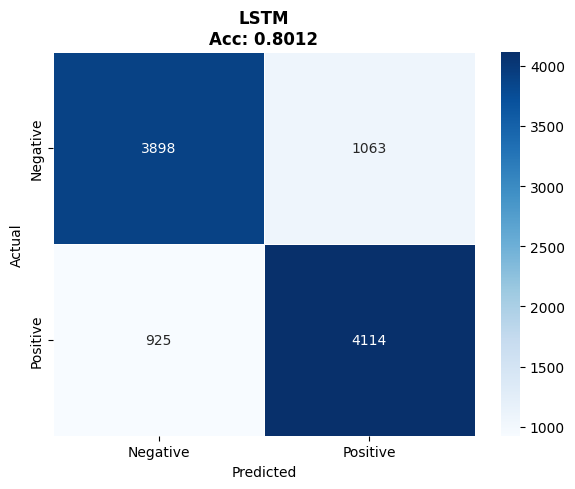

In [20]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Resultados da Classificação

In [21]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.81      0.79      0.80      4961
    Positive       0.79      0.82      0.81      5039

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



# Teste de Outputs


In [22]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

x = X_test_pad[0].tolist()

outputs = inspection_model.predict(np.array([x]))

# salva em txt
with open("layer_outputs_simplified_model.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs_simplified_model.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 730ms/step
Outputs salvos em layer_outputs_simplified_model.txt


# Exportação de Pesos

In [23]:
export_weights(lstm_model, mode='lstm', output_file="../../Geral Tests SystemVerilog/Simplest Neural Network/weights.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos a partir da primeira LSTM
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x08000 Wx_input[0][0] = 0.151423
  addr=0x08001 Wx_input[0][1] = -0.113860
  addr=0x08080 Wx_input[1][0] = 0.010775
  addr=0x08081 Wx_input[1][1] = 0.318696
  addr=0x08040 Wh_input[0][0] = -0.226885
  addr=0x08041 Wh_input[0][1] = -0.121314
  addr=0x080C0 Wh_input[1][0] = -0.135579
  addr=0x080C1 Wh_input[1][1] = 0.106893
  addr=0x18000 bias_input[0] = 0.119321
  addr=0x18080 bias_input[1] = 0.159041
  addr=0x0A000 Wx_forget[0][0] = 0.117003
  addr=0x0A001 Wx_forget[0][1] = -0.187944
  addr=0x0A080 Wx_forget[1][0] = 0.314509
  addr=0x0A081 Wx_forget[1][1] = -0.269843
  addr=0x0A040 Wh_forget[0][0] = -0.002738
  addr=0x0A041 Wh_forget[0][1] = -0.066391
  addr=0x0A0C0 Wh_forget[1][0] = -0.165137
  addr=0x0A0C1 Wh_forget[1][1] = -0.182316
  addr=0x1A000 bias_forget[0] = 1.063400
  addr=0x1A080 bias_forget[1] = 1.052192
  addr=0x0C000 Wx_candidate[0][0] = -0.551486
  addr=

# Teste Global

In [24]:
FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q16(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)


In [25]:
def export_matrix_to_mem(matrix,result,ground_result, output_file="matrix.mem"):
    mem = {}
    
    for linha_idx in range(matrix.shape[0]):
        for col_idx in range(4):
            addr = (linha_idx << 2) | col_idx
            valor = matrix[linha_idx, col_idx]
            valor_q16 = float_to_q16(valor)  # sua função original
            mem[addr] = valor_q16
    
    # ESCREVE EXATAMENTE COMO NO SEU CÓDIGO ORIGINAL
    with open(output_file, "w") as f:
        line = 0
        result_hex = float_to_q16(result)
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])  # ← igual ao original
            if line == 0:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X} {int(result_hex) & 0xFFFFFFFF:08X}  {int(ground_result) & 0xFFFFFFFF:01X}   \n")
            else:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
            line+=1
    print(f"Arquivo salvo: {output_file}")
    return mem

In [26]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)
total = len(y_pred_lstm)
#total = 50

for i in range(total):
    x = np.array([X_test_pad[i].tolist()])

    #outputs = inspection_model.predict(x)
    
    #export_matrix_to_mem(outputs[0][0], outputs[6][0][0], y_test.values[i], f"../../Geral Tests SystemVerilog/Simplest Neural Network/Small Global Processing/dados_{i}.mem")

    print(f"{i} de {total}")

0 de 10000
1 de 10000
2 de 10000
3 de 10000
4 de 10000
5 de 10000
6 de 10000
7 de 10000
8 de 10000
9 de 10000
10 de 10000
11 de 10000
12 de 10000
13 de 10000
14 de 10000
15 de 10000
16 de 10000
17 de 10000
18 de 10000
19 de 10000
20 de 10000
21 de 10000
22 de 10000
23 de 10000
24 de 10000
25 de 10000
26 de 10000
27 de 10000
28 de 10000
29 de 10000
30 de 10000
31 de 10000
32 de 10000
33 de 10000
34 de 10000
35 de 10000
36 de 10000
37 de 10000
38 de 10000
39 de 10000
40 de 10000
41 de 10000
42 de 10000
43 de 10000
44 de 10000
45 de 10000
46 de 10000
47 de 10000
48 de 10000
49 de 10000
50 de 10000
51 de 10000
52 de 10000
53 de 10000
54 de 10000
55 de 10000
56 de 10000
57 de 10000
58 de 10000
59 de 10000
60 de 10000
61 de 10000
62 de 10000
63 de 10000
64 de 10000
65 de 10000
66 de 10000
67 de 10000
68 de 10000
69 de 10000
70 de 10000
71 de 10000
72 de 10000
73 de 10000
74 de 10000
75 de 10000
76 de 10000
77 de 10000
78 de 10000
79 de 10000
80 de 10000
81 de 10000
82 de 10000
83 de 10000
84